# Ταξινομηση Ασθενειων Φυτων με Convolutional Neural Network

Σε αυτο το notebook φτιαχνω ενα **CNN** που ταξινομει εικονες φυλλων φυτων σε **38 κατηγοριες** (υγιη φυτα και διαφορες ασθενειες).

**Dataset:** PlantVillage (~54.000 εικονες) - φορτωνεται αυτοματα μεσω TensorFlow Datasets, δεν χρειαζεται download απο Kaggle.

**Βηματα:**
1. Ελεγχος GPU
2. Φορτωση δεδομενων
3. Εξερευνηση δειγματων
4. Προεπεξεργασια
5. Κατασκευη του CNN (baseline)
6. Εκπαιδευση baseline
7. Καμπυλες εκπαιδευσης
8. Αξιολογηση στο test set
9. Confusion matrix
10. Παραδειγματα προβλεψεων
11. Hyperparameter Tuning με Keras Tuner
12. Εκπαιδευση τελικου μοντελου
13. Συγκριση Baseline vs Tuned

## 1. Ελεγχος GPU

Βεβαιωνομαστε οτι το Colab χρησιμοποιει GPU.

In [ ]:
import tensorflow as tf

# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
# print(f"GPU available: {len(gpus) > 0}")
# print(f"Devices: {gpus}")

## 2. Βιβλιοθηκες

Φορτωνω ολα τα απαραιτητα packages. Ολα ειναι ηδη εγκατεστημενα στο Colab.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# print("TensorFlow version:", tf.__version__)

## 3. Φορτωση δεδομενων

Καετβαζω το PlantVillage dataset. Την πρωτη φορα θα παρει 1-2 λεπτα.

Χωριζω τα δεδομενα σε:
- **Train set:** 70% (για εκπαιδευση)
- **Validation set:** 15% (για ελεγχο κατα την εκπαιδευση)
- **Test set:** 15% (για τελικη αξιολογηση σε δεδομενα που δεν εχει δει το μοντελο)

In [ ]:
# Load PlantVillage dataset and split into train/val/test
(ds_train, ds_val, ds_test), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = info.features['label'].num_classes
CLASS_NAMES = info.features['label'].names

print(f"Number of classes: {NUM_CLASSES}")
print(f"Total images: {info.splits['train'].num_examples}")
print(f"\nFirst 10 class names:")
for i, name in enumerate(CLASS_NAMES[:10]):
    print(f"  {i}: {name}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.CEUZOF_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Number of classes: 38
Total images: 54303

First 10 class names:
  0: Apple___Apple_scab
  1: Apple___Black_rot
  2: Apple___Cedar_apple_rust
  3: Apple___healthy
  4: Blueberry___healthy
  5: Cherry___healthy
  6: Cherry___Powdery_mildew
  7: Corn___Cercospora_leaf_spot Gray_leaf_spot
  8: Corn___Common_rust
  9: Corn___healthy


## 4. Εξερευνηση δειγματων

Δειχνω 9 τυχαιες εικονες απο το training set μαζι με την κατηγορια τους, για να δω πως ειναι φορτωμενα τα δεδομενα.

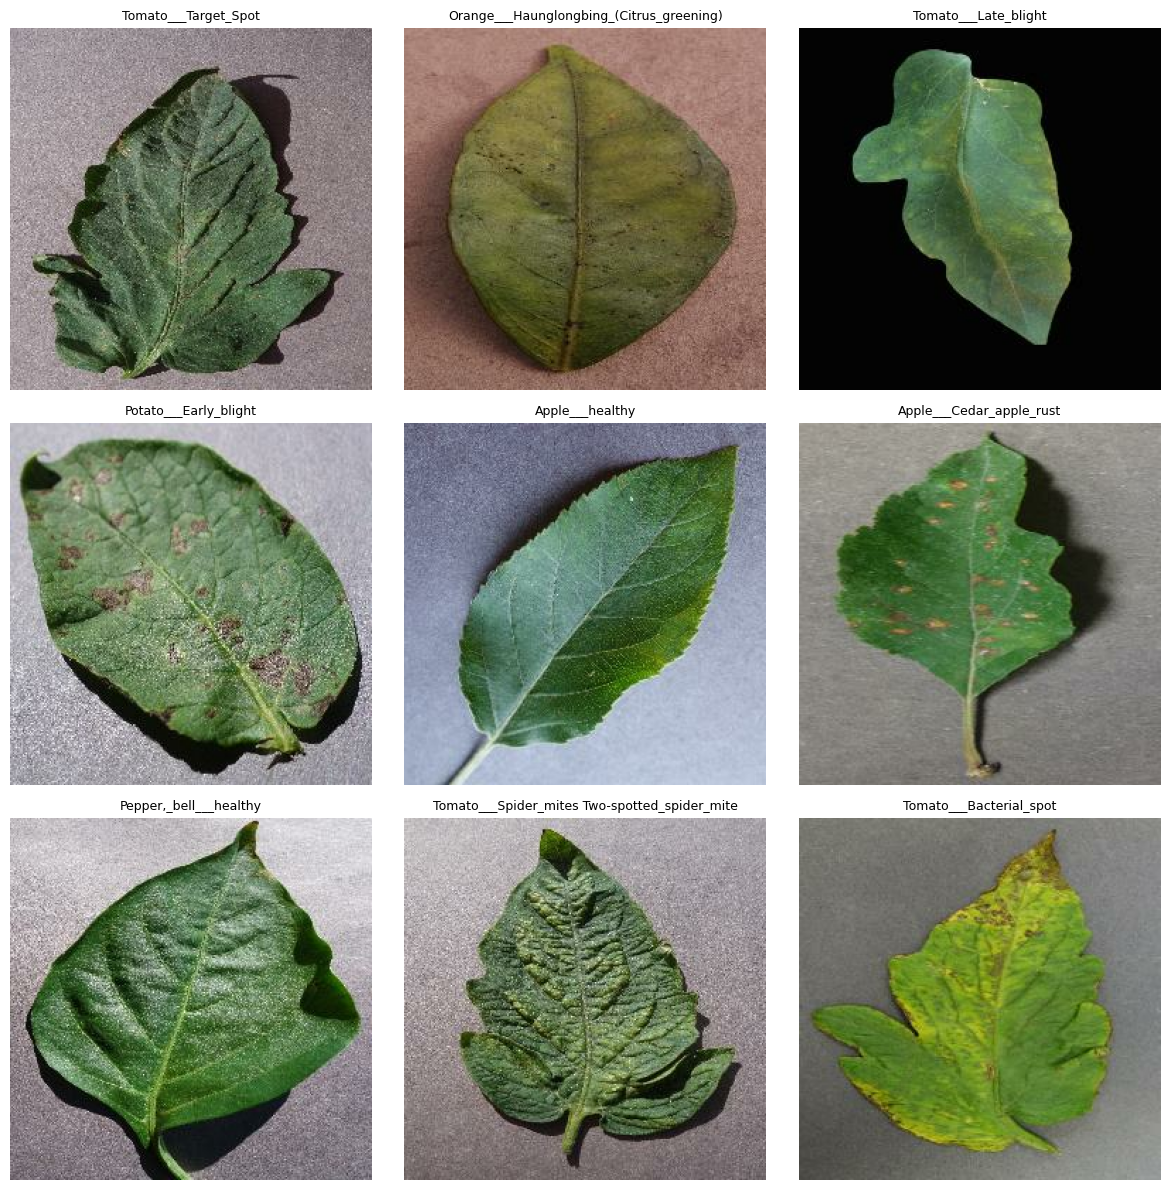

In [ ]:
# Display 9 sample images with their labels
plt.figure(figsize=(12, 12))
for i, (image, label) in enumerate(ds_train.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy())
    plt.title(CLASS_NAMES[label.numpy()], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Προεπεξεργασια

Πριν δωσω τα δεδομενα στο μοντελο πρεπει:

- **Resize:** ολες οι εικονες σε 128x128 pixels (μικροτερο μεγεθος = πιο γρηγορη εκπαιδευση)
- **Normalize:** οι τιμες των pixels πανε απο [0, 255] σε [0, 1]
- **Data augmentation** (μονο στο training): random horizontal flip και brightness, για να βοηθησουμε το μοντελο να μην κανει overfit
- **Batch size:** 64 εικονες ανα batch
- **Prefetch:** το pipeline ετοιμαζει το επομενο batch οσο εκπαιδευεται το προηγουμενο

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 64

# Resize images and normalize pixel values to [0, 1]
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Data augmentation - applied only to training set
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# Build the training pipeline (with augmentation + shuffle)
ds_train_prepared = (ds_train
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Validation pipeline (no augmentation, no shuffle)
ds_val_prepared = (ds_val
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Test pipeline (no augmentation, no shuffle)
ds_test_prepared = (ds_test
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

print("Data pipelines ready")

Data pipelines ready


## 6. Κατασκευη του CNN (baseline)

Φτιαχνω ενα **custom CNN** απο την αρχη με 4 convolutional blocks. Καθε block εχει:

- **Conv2D:** ανιχνευει χαρακτηριστικα στην εικονα (ακμες, χρωματα, υφες, μοτιβα)
- **BatchNormalization:** σταθεροποιει την εκπαιδευση και τη κανει πιο γρηγορη
- **MaxPooling2D:** μειωνει τη διασταση της εικονας στο μισο

Αρχιτεκτονικη:

```
Input (128x128x3)
  |
[Conv2D 32  + BN + MaxPool] -> block 1: βασικα χαρακτηριστικα (ακμες, χρωματα)
  |
[Conv2D 64  + BN + MaxPool] -> block 2: πιο συνθετα μοτιβα (υφες)
  |
[Conv2D 128 + BN + MaxPool] -> block 3: μεγαλυτερες δομες (κηλιδες)
  |
[Conv2D 128 + BN + MaxPool] -> block 4: υψηλου επιπεδου χαρακτηριστικα
  |
GlobalAveragePooling2D      -> συμπυκνωνει σε ενα διανυσμα
  |
Dense(128) + Dropout(0.4)   -> classification layer + regularization
  |
Dense(38) softmax           -> πιθανοτητες για καθε κατηγορια
```

Αυτο ειναι το **baseline** μοντελο μου με χειροκινητα επιλεγμενες υπερπαραμετρους. Μετα θα κανω tuning για να δω αν μπορω να το βελτιωσω.

In [ ]:
from tensorflow.keras import layers, models

# Build the custom CNN architecture
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,654 (1.01 MB)

 Trainable params: 262,950 (1.00 MB)

 Non-trainable params: 704 (2.75 KB)

## 7. Εκπαιδευση baseline

Εκαπιδευω για **10 epochs**. Καθε epoch θα παρει περιπου 1 λεπτο στο Colab GPU (T4).
Συνολικα ~10-15 λεπτα.

*Σε καθε epoch το μοντελο βλεπει ολο το training set και προσαρμοζει τα βαρη του*.

In [ ]:
EPOCHS = 10

history = model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=EPOCHS
)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.6385 - loss: 1.2617 - val_accuracy: 0.3748 - val_loss: 2.6988
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8446 - loss: 0.4935 - val_accuracy: 0.7043 - val_loss: 1.0824
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9042 - loss: 0.3009 - val_accuracy: 0.8054 - val_loss: 0.6114
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9300 - loss: 0.2201 - val_accuracy: 0.8197 - val_loss: 0.6622
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9451 - loss: 0.1718 - val_accuracy: 0.6775 - val_loss: 1.7729
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9547 - loss: 0.1432 - val_accuracy: 0.9192 - val_loss: 0.2394
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9597 - loss: 0.1246 - val_accuracy: 0.8517 - val_loss: 0.4795
Epoch 8/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9619 - loss: 0.1158 - val_acc

## 8. Καμπυλες εκπαιδευσης

σχεδιαζω πως εξελιχθηκαν το **accuracy** και το **loss** σε train και validation set.

**Πως να τα διβασει ο αναγωνστης:**
- Αν το train accuracy ειναι πολυ μεγαλυτερο απο το validation accuracy → **overfitting** (το μοντελο μαθαινει απο μνημης)
- Αν και τα δυο ανεβαινουν μαζι → καλη εκπαιδευση
- Αν το loss σταθεροποιειται → φτασαμε στο plateua, ισως χρειαζεται lower learning rate

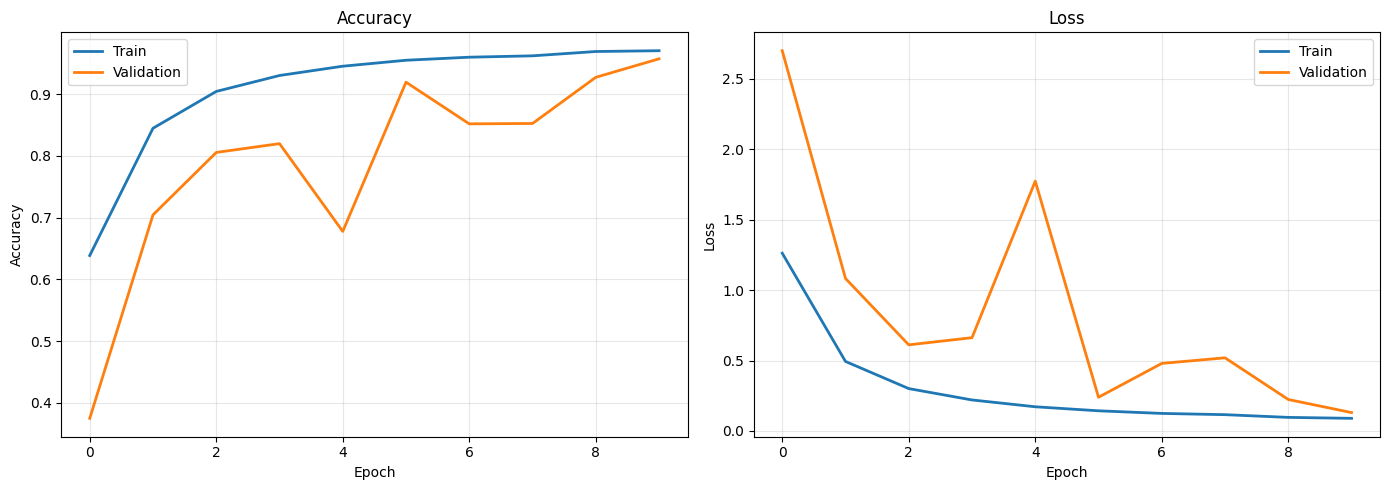

In [ ]:
# Plot training and validation curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Αξιολογηση στο test set (baseline)

υπολογιζω το τελικο **test accuracy** σε δεδομενα που το μοντελο **δεν εχει ξαναδει**.
Αυτος ειναι ο πιο αξιοπιστος δεικτης για το ποσο καλα γενικευει το μοντελο.

In [ ]:
# Final evaluation on the held-out test set
test_loss, test_acc = model.evaluate(ds_test_prepared, verbose=0)
print(f"Baseline test accuracy: {test_acc * 100:.2f}%")
print(f"Baseline test loss:     {test_loss:.4f}")

Baseline test accuracy: 95.75%
Baseline test loss:     0.1281


## 10. Confusion Matrix

Δειχνει σε ποιες κατηγοριες κανει λαθη το μοντελο:
- **Διαγωνιος** = σωστες προβλεψεις (οσο πιο σκουρα, τοσο καλυτερα)
- **Εκτος διαγωνιου** = λαθη (true label vs predicted label)

Με 38 κλασεις φαινεται πυκνο, αλλα μπορω με αυτον τον τροπο να εντοπισω ζευγη κατηγοριων που μπερδευονται μεταξυ τους.

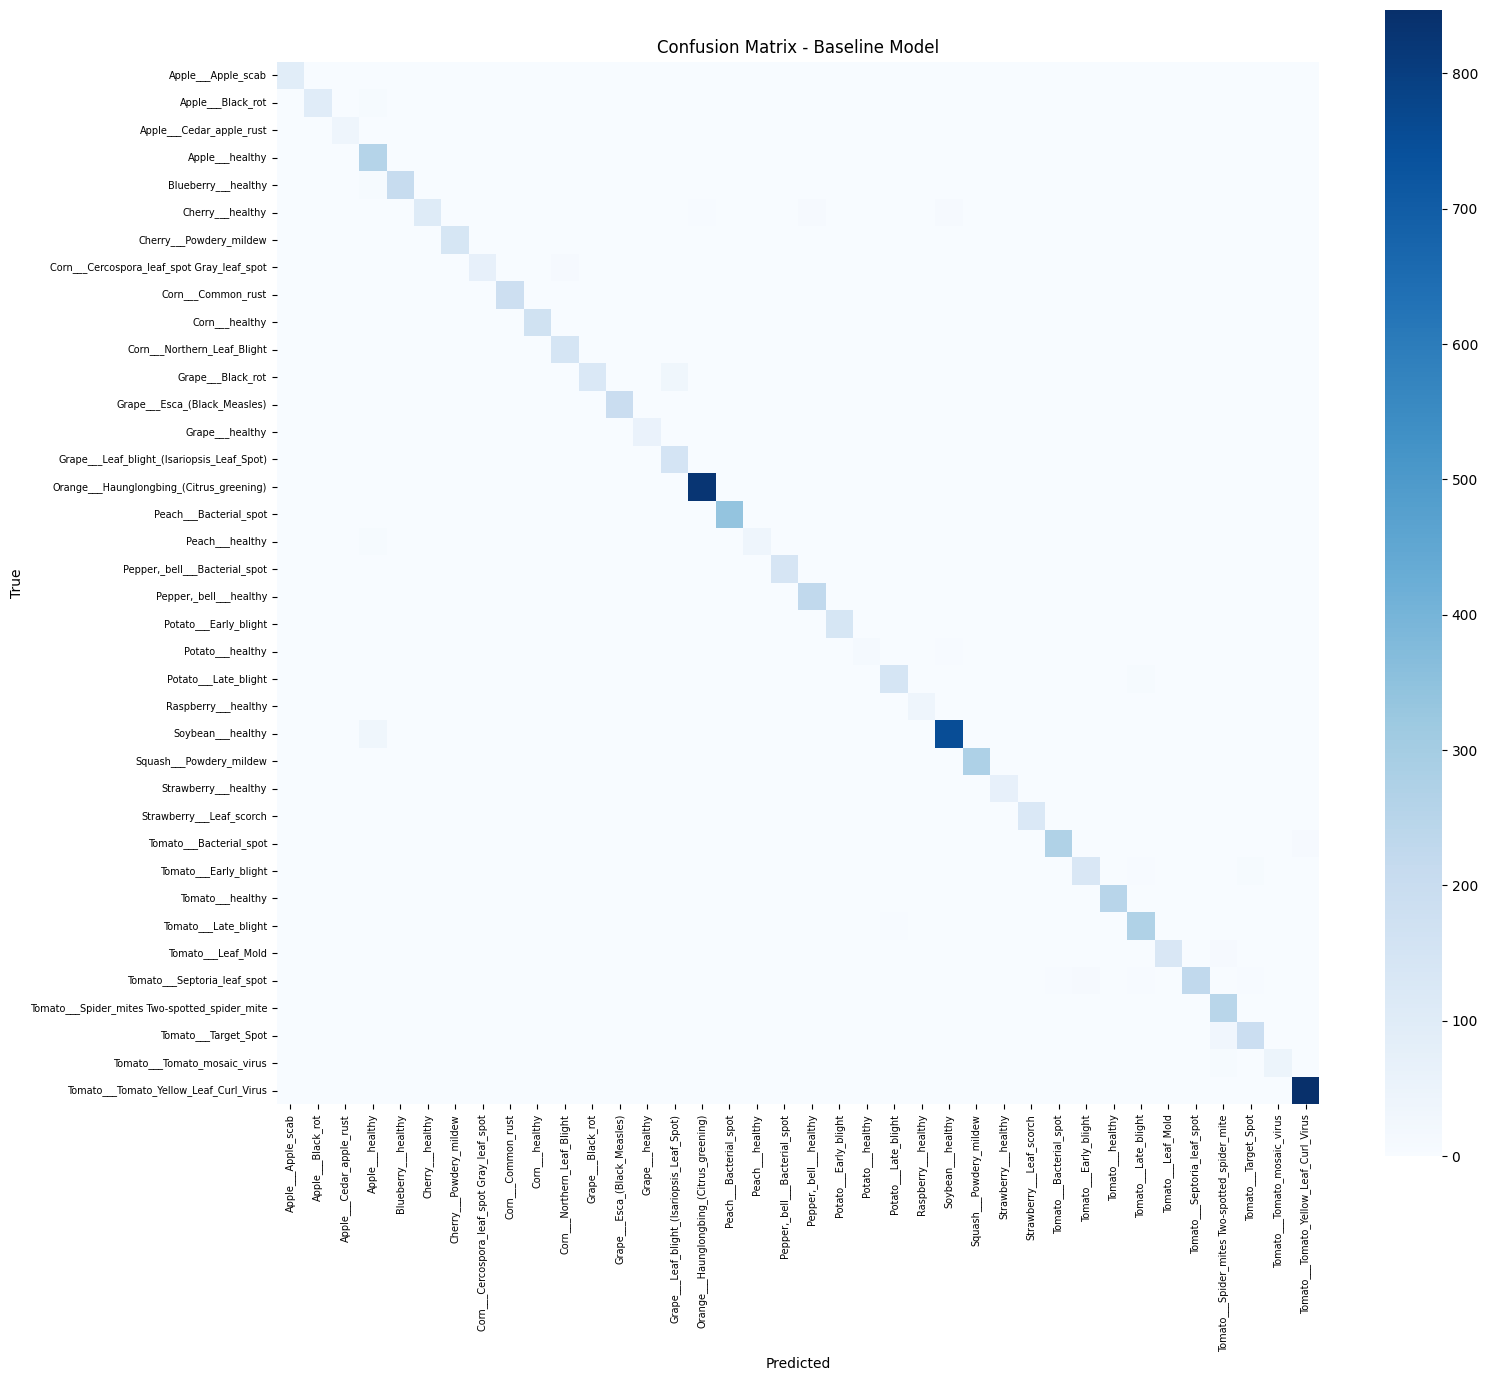

In [ ]:
# Get predictions on the entire test set
y_true = []
y_pred = []

for images, labels in ds_test_prepared:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues', cbar=True, square=True,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline Model')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## 11. Παραδειγματα προβλεψεων

Δειχνω 9 τυχαιες εικονες απο το test set με την προβλεψη του μοντελου, την πραγματικη κατηγορια και το confidence (ποσο σιγουρο ηταν).

- 🟢 **τιτλος:** σωστη προβλεψη
- 🔴 **τιτλος:** λαθος προβλεψη

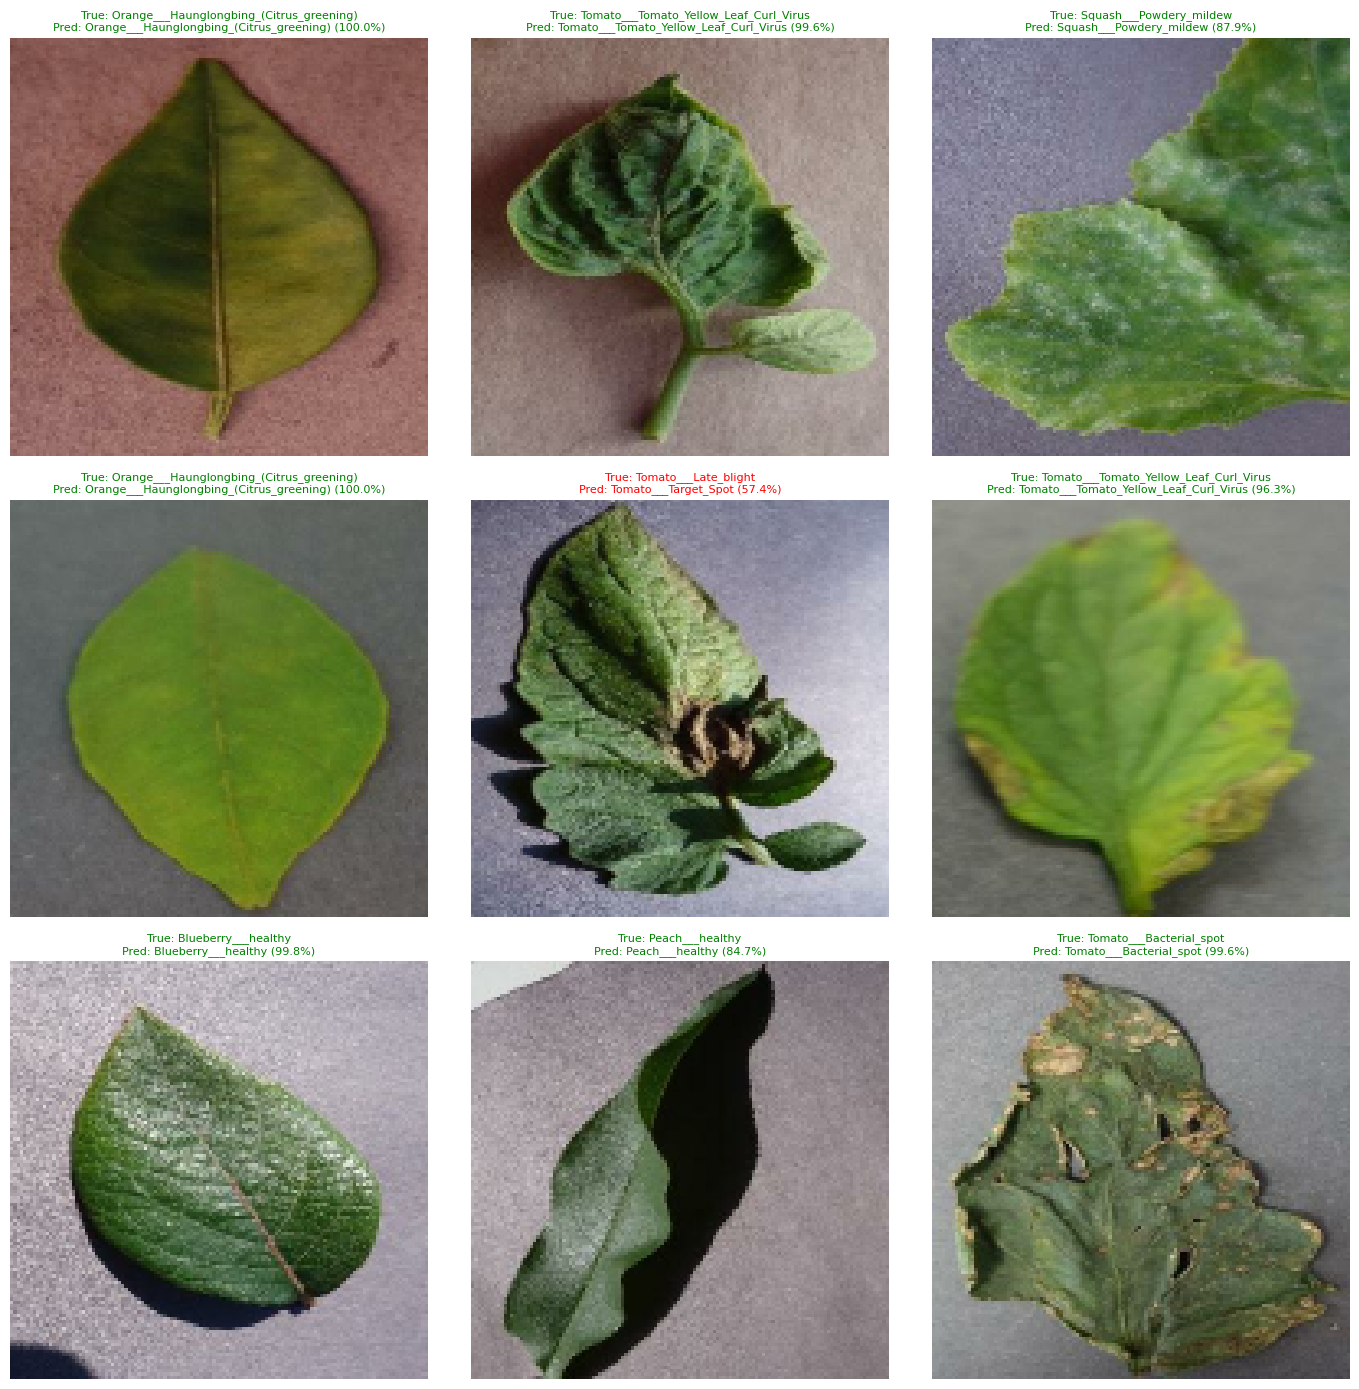

In [ ]:
# Take one batch of test images and predict
for images, labels in ds_test_prepared.take(1):
    test_images = images.numpy()
    test_labels = labels.numpy()
    break

predictions = model.predict(test_images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# Show 9 random samples with predictions
indices = np.random.choice(len(test_images), 9, replace=False)

plt.figure(figsize=(14, 14))
for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[idx])

    true_label = CLASS_NAMES[test_labels[idx]]
    pred_label = CLASS_NAMES[predicted_labels[idx]]
    confidence = predictions[idx][predicted_labels[idx]] * 100

    is_correct = test_labels[idx] == predicted_labels[idx]
    color = 'green' if is_correct else 'red'

    title = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
    plt.title(title, fontsize=8, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning με Keras Tuner

Μεχρι τωρα επελεξα **χειροκινητα** τις υπερπαραμετρους (dropout=0.4, dense_units=128, learning_rate=1e-3). Αλλα ειναι οι καλυτερες;

Θα χρησ/σω το **Keras Tuner** για να δοκιμασω αυτοματα διαφορετικους συνδυασμους και να βρω τον καλυτερο συμφωνα με το **validation accuracy**.

**Τι θα κανω tune:**

| Hyperparameter | Τιμες προς δοκιμη |
|---|---|
| `dropout_rate` | 0.2, 0.3, 0.4, 0.5 |
| `dense_units` | 64, 128, 256 |
| `learning_rate` | 1e-3, 5e-4, 1e-4 |

**Στρατηγικη:** RandomSearch με 5 trials, 5 epochs ανα trial.

> **Προς ενημερωση:** Αυτο το βημα ειναι αργο! Θα παρει ~25 λεπτα. Μπορει καποιος να το παραλειψει αν εισαι ικανοποιημενος με το baseline.

In [ ]:
# Install keras-tuner (usually available on Colab, but ensure it's there)
!pip install -q keras-tuner

import keras_tuner as kt

# print(f"Keras Tuner version: {kt.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.5 MB/s eta 0:00:00


### 12.1 Συναρτηση κατασκευης μοντελου με υπερπαραμετρους

Φτιαχνω μια συναρτηση `build_model(hp)` που δεχεται ενα αντικειμενο `hp` (HyperParameters) και χτιζει ενα μοντελο με τις τιμες που θα δοκιμαστουν. Ο tuner καλει αυτη τη συναρτηση πολλες φορες με διαφορετικες τιμες.

In [ ]:
# Function that builds a CNN model given a set of hyperparameters
def build_model(hp):
    # Define the search space for each hyperparameter
    dropout_rate = hp.Choice('dropout', values=[0.2, 0.3, 0.4, 0.5])
    dense_units = hp.Choice('dense_units', values=[64, 128, 256])
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    # Same architecture as baseline, but dropout/dense/lr are now tunable
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_model function ready")

build_model function ready


### 12.2 Εκτελεση της αναζητησης

Ο `RandomSearch` διαλεγει τυχαιους συνδυασμους υπερπαραμετρων και εκπαιδευει το μοντελο για 5 epochs ανα συνδυασμο. Κραταει αυτον με το **καλυτερο val_accuracy**.

Αναμενομενος χρονος: ~25 λεπτα στο Colab GPU (5 trials × 5 epochs).

In [ ]:
# Set up the Random Search tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,                # Number of HP combinations to try
    executions_per_trial=1,
    directory='kt_results',
    project_name='plant_disease',
    overwrite=True
)

# Show the search space
tuner.search_space_summary()

# Run the search (this is the slow step)
tuner.search(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=5,
    verbose=1
)

print("\nSearch complete!")

Trial 5 Complete [00h 00m 57s]
val_accuracy: 0.8922170400619507

Best val_accuracy So Far: 0.9195924401283264
Total elapsed time: 00h 05m 16s

Search complete!


### 12.3 Καλυτερες υπερπαραμετροι

Παιρνω τον συνδυασμο που εδωσε το υψηλοτερο validation accuracy και βλεπω ολους τους συνδυασμους που δοκιμαστηκαν.

In [ ]:
# Get the best hyperparameters from the search
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 50)
print(f"  dropout_rate:  {best_hps.get('dropout')}")
print(f"  dense_units:   {best_hps.get('dense_units')}")
print(f"  learning_rate: {best_hps.get('learning_rate')}")
print("=" * 50)

# Show summary of all trials
print("\nAll trials summary:\n")
tuner.results_summary(num_trials=5)

BEST HYPERPARAMETERS FOUND
  dropout_rate:  0.4
  dense_units:   64
  learning_rate: 0.0005

All trials summary:

Results summary
Results in kt_results/plant_disease
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
dropout: 0.4
dense_units: 64
learning_rate: 0.0005
Score: 0.9195924401283264

Trial 2 summary
Hyperparameters:
dropout: 0.5
dense_units: 256
learning_rate: 0.0001
Score: 0.9130861759185791

Trial 1 summary
Hyperparameters:
dropout: 0.4
dense_units: 256
learning_rate: 0.001
Score: 0.905720591545105

Trial 4 summary
Hyperparameters:
dropout: 0.5
dense_units: 256
learning_rate: 0.001
Score: 0.8922170400619507

Trial 0 summary
Hyperparameters:
dropout: 0.3
dense_units: 64
learning_rate: 0.001
Score: 0.8644733428955078


## 13. Εκπαιδευση του τελικου μοντελου

Με τις καλυτερες υπερπαραμετρους που βρηκα, εκπαιδευω το **τελικο μοντελο για 15 epochs** (περισσοτερα απο το baseline για να δω αν μπορει να φτασει σε υψηλοτερο accuracy).

In [ ]:
# Build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

best_model.summary()

# Train for more epochs now that we have the best HPs
history_best = best_model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=15
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,966 (988.15 KB)

 Trainable params: 252,262 (985.40 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.5625 - loss: 1.6135 - val_accuracy: 0.4022 - val_loss: 2.6372
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7749 - loss: 0.7620 - val_accuracy: 0.8783 - val_loss: 0.4291
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8552 - loss: 0.4845 - val_accuracy: 0.8624 - val_loss: 0.4630
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8982 - loss: 0.3434 - val_accuracy: 0.8124 - val_loss: 0.5960
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9176 - loss: 0.2702 - val_accuracy: 0.8822 - val_loss: 0.3701
Epoch 6/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9327 - loss: 0.2190 - val_accuracy: 0.8618 - val_loss: 0.4485
Epoch 7/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9426 - loss: 0.1887 - val_accuracy: 0.8944 - val_loss: 0.3348
Epoch 8/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9497 - loss: 0.1641 - val_acc

## 14. Συγκριση Baseline vs Tuned μοντελο

Συγκρινω τα δυο μοντελα στο test set και δειχνω τις καμπυλες validation accuracy/loss για να δω αν το tuning εκανε (τελικα) τη διαφορα.

  Baseline test accuracy: 95.75%
  Tuned    test accuracy: 88.73%
  Improvement:            -7.02%


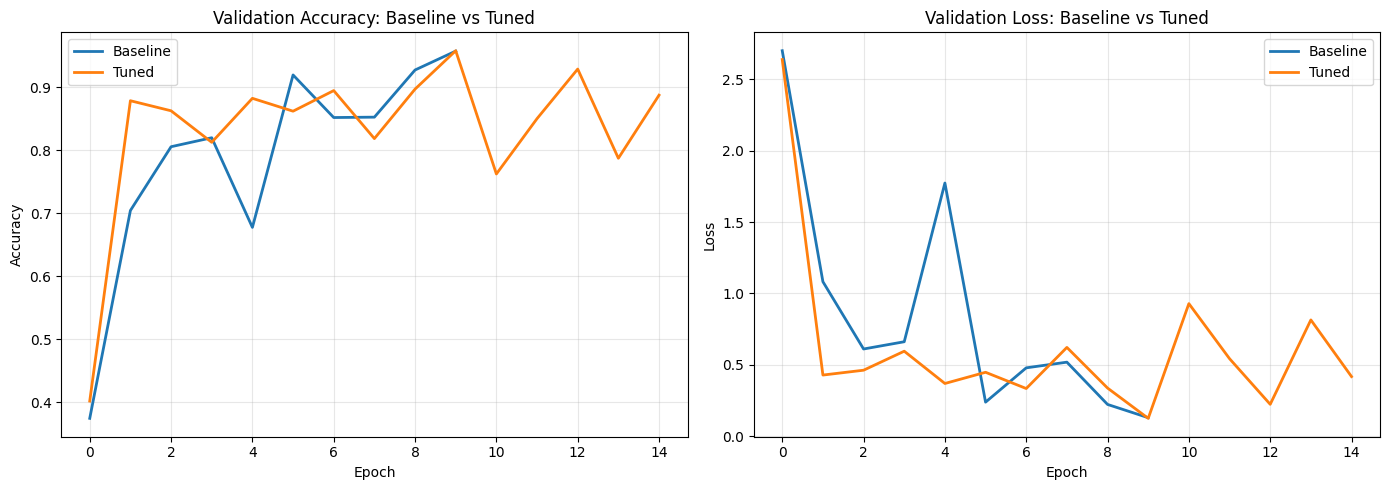

In [ ]:
# Evaluate the tuned model on the test set
test_loss_best, test_acc_best = best_model.evaluate(ds_test_prepared, verbose=0)

# Print comparison
print("=" * 55)
print(f"  Baseline test accuracy: {test_acc * 100:.2f}%")
print(f"  Tuned    test accuracy: {test_acc_best * 100:.2f}%")
print(f"  Improvement:            {(test_acc_best - test_acc) * 100:+.2f}%")
print("=" * 55)

# Plot comparison curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['val_accuracy'], label='Baseline', linewidth=2)
axes[0].plot(history_best.history['val_accuracy'], label='Tuned', linewidth=2)
axes[0].set_title('Validation Accuracy: Baseline vs Tuned')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['val_loss'], label='Baseline', linewidth=2)
axes[1].plot(history_best.history['val_loss'], label='Tuned', linewidth=2)
axes[1].set_title('Validation Loss: Baseline vs Tuned')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Transfer Learning με ResNet50

Μεχρι τωρα χρησιμοποιησα ενα custom CNN. Τωρα θα δοκιμασω **transfer learning** με το **ResNet50** - ενα προ-εκπαιδευμενο βαθυ δικτυο (50 layers) που εχει ηδη μαθει features απο το ImageNet (1.2M εικονες).

**Στρατηγικη:**
- Παγωνω (freeze) το pre-trained backbone του ResNet50
- Προσθετω δικο μου classification head (Dense + Dropout + softmax)
- Εκπαιδευω **μονο** το head

Το ResNet50 χρειαζεται εικονες **224x224** και ειδικη preprocessing. Φτιαχνω νεα data pipelines.

In [ ]:
# ResNet50 needs 224x224 images and its own preprocessing
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

IMG_SIZE_RESNET = 224

# Resize and apply ResNet-specific preprocessing (NOT /255)
def preprocess_resnet(image, label):
    image = tf.image.resize(image, (IMG_SIZE_RESNET, IMG_SIZE_RESNET))
    image = resnet_preprocess(tf.cast(image, tf.float32))
    return image, label

# Build new pipelines for ResNet
ds_train_resnet = (ds_train
    .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

ds_val_resnet = (ds_val
    .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

ds_test_resnet = (ds_test
    .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

print("ResNet50 data pipelines ready")

ResNet50 data pipelines ready


### 15.1 Κατασκευη του ResNet50 baseline

- Φορτωνω το ResNet50 με βαρη απο ImageNet (`weights='imagenet'`)
- `include_top=False`: αφαιρω το αρχικο classification layer (1000 ImageNet classes)
- `trainable=False`: παγωνω το backbone, μενουν trainable μονο τα νεα layers

In [ ]:
from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50 (without the top classification layer)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE_RESNET, IMG_SIZE_RESNET, 3)
)

# Freeze the backbone - only train the new classification head
base_model.trainable = False

# Build the full model
model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,854,886 (91.00 MB)

 Trainable params: 267,174 (1.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 15.2 Εκπαιδευση ResNet50 baseline

Εκπαιδευω για 10 epochs. Κανονικα συγκλινει πολυ γρηγορα γιατι τα features ειναι ηδη μαθημενα.

In [ ]:
history_resnet = model_resnet.fit(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=10
)

# Evaluate on test set
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(ds_test_resnet, verbose=0)
print(f"\nResNet50 baseline test accuracy: {test_acc_resnet * 100:.2f}%")

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - accuracy: 0.8296 - loss: 0.6181 - val_accuracy: 0.9581 - val_loss: 0.1439
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9347 - loss: 0.2052 - val_accuracy: 0.9741 - val_loss: 0.0903
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9515 - loss: 0.1511 - val_accuracy: 0.9756 - val_loss: 0.0756
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9591 - loss: 0.1244 - val_accuracy: 0.9785 - val_loss: 0.0678
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9630 - loss: 0.1099 - val_accuracy: 0.9808 - val_loss: 0.0583
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9670 - loss: 0.0988 - val_accuracy: 0.9774 - val_loss: 0.0643
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9703 - loss: 0.0879 - val_accuracy: 0.9815 - val_loss: 0.0533
Epoch 8/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9718 - loss: 0.0818 - 

## 16. ResNet50 με Hyperparameter Tuning

Κανω tuning στο classification head του ResNet50 (το backbone παραμενει frozen).

**Tunable params:**
- `dropout_rate`: 0.2, 0.3, 0.4, 0.5
- `dense_units`: 64, 128, 256
- `learning_rate`: 1e-3, 5e-4, 1e-4

In [ ]:
def build_resnet_model(hp):
    # Define the search space
    dropout_rate = hp.Choice('dropout', values=[0.2, 0.3, 0.4, 0.5])
    dense_units = hp.Choice('dense_units', values=[64, 128, 256])
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    # Fresh ResNet50 backbone (frozen)
    backbone = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_RESNET, IMG_SIZE_RESNET, 3)
    )
    backbone.trainable = False

    model = models.Sequential([
        backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Set up the tuner for ResNet
tuner_resnet = kt.RandomSearch(
    build_resnet_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='kt_results_resnet',
    project_name='plant_disease_resnet',
    overwrite=True
)

tuner_resnet.search_space_summary()

# Run the search
tuner_resnet.search(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=5,
    verbose=1
)

print("\nResNet tuning complete!")

Trial 5 Complete [00h 02m 32s]
val_accuracy: 0.9797446727752686

Best val_accuracy So Far: 0.981095016002655
Total elapsed time: 00h 12m 43s

ResNet tuning complete!


### 16.1 Καλυτερες υπερπαραμετροι για ResNet

In [ ]:
# Get the best hyperparameters
best_hps_resnet = tuner_resnet.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("BEST RESNET HYPERPARAMETERS")
print("=" * 50)
print(f"  dropout_rate:  {best_hps_resnet.get('dropout')}")
print(f"  dense_units:   {best_hps_resnet.get('dense_units')}")
print(f"  learning_rate: {best_hps_resnet.get('learning_rate')}")
print("=" * 50)

print("\nAll trials summary:\n")
tuner_resnet.results_summary(num_trials=5)

BEST RESNET HYPERPARAMETERS
  dropout_rate:  0.3
  dense_units:   128
  learning_rate: 0.0005

All trials summary:

Results summary
Results in kt_results_resnet/plant_disease_resnet
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
dropout: 0.3
dense_units: 128
learning_rate: 0.0005
Score: 0.981095016002655

Trial 4 summary
Hyperparameters:
dropout: 0.3
dense_units: 128
learning_rate: 0.001
Score: 0.9797446727752686

Trial 3 summary
Hyperparameters:
dropout: 0.2
dense_units: 64
learning_rate: 0.0005
Score: 0.9770439267158508

Trial 1 summary
Hyperparameters:
dropout: 0.2
dense_units: 256
learning_rate: 0.0001
Score: 0.9765529036521912

Trial 2 summary
Hyperparameters:
dropout: 0.2
dense_units: 128
learning_rate: 0.0001
Score: 0.9700466394424438


### 16.2 Εκπαιδευση τελικου ResNet μοντελου

Με τις καλυτερες υπερπαραμετρους, εκπαιδευω για 15 epochs.

In [ ]:
# Build and train the final ResNet model with best HPs
best_model_resnet = tuner_resnet.hypermodel.build(best_hps_resnet)

history_resnet_best = best_model_resnet.fit(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=15
)

# Evaluate on test set
test_loss_resnet_best, test_acc_resnet_best = best_model_resnet.evaluate(ds_test_resnet, verbose=0)
print(f"\nResNet50 tuned test accuracy: {test_acc_resnet_best * 100:.2f}%")

Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 48s 60ms/step - accuracy: 0.8396 - loss: 0.6053 - val_accuracy: 0.9597 - val_loss: 0.1478
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9466 - loss: 0.1790 - val_accuracy: 0.9712 - val_loss: 0.0974
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9633 - loss: 0.1217 - val_accuracy: 0.9747 - val_loss: 0.0811
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9706 - loss: 0.0929 - val_accuracy: 0.9797 - val_loss: 0.0645
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9773 - loss: 0.0735 - val_accuracy: 0.9812 - val_loss: 0.0593
Epoch 6/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9792 - loss: 0.0638 - val_accuracy: 0.9834 - val_loss: 0.0550
Epoch 7/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9810 - loss: 0.0572 - val_accuracy: 0.9821 - val_loss: 0.0550
Epoch 8/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9844 - loss: 0.0473 - 

## 17. Τελικη συγκριση και των 4 μοντελων

Συγκρινω και τα 4 μοντελα στο test set:

1. **Simple CNN (baseline)** - custom CNN, χειροκινητες υπερπαραμετροι
2. **Simple CNN (tuned)** - custom CNN, βελτιστοποιημενες με RandomSearch
3. **ResNet50 (baseline)** - transfer learning με frozen backbone
4. **ResNet50 (tuned)** - transfer learning με βελτιστοποιημενο head

Model                          Test Accuracy
Simple CNN (baseline)                 95.75%
Simple CNN (tuned)                    88.73%
ResNet50 (baseline)                   98.61%
ResNet50 (tuned)                      98.65%

Best model: ResNet50 (tuned) (98.65%)


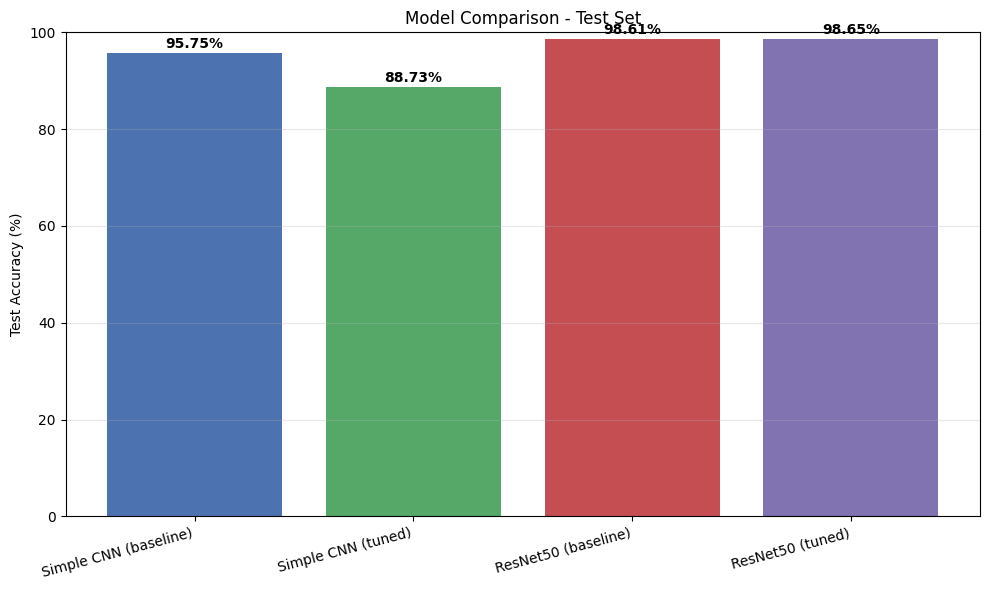

In [ ]:
# Build a comparison table and bar chart
results = {
    'Simple CNN (baseline)':  test_acc,
    'Simple CNN (tuned)':     test_acc_best,
    'ResNet50 (baseline)':    test_acc_resnet,
    'ResNet50 (tuned)':       test_acc_resnet_best,
}

# Print comparison table
print("=" * 55)
print(f"{'Model':<28} {'Test Accuracy':>15}")
print("=" * 55)
for name, acc in results.items():
    print(f"{name:<28} {acc * 100:>14.2f}%")
print("=" * 55)
best_name = max(results, key=results.get)
print(f"\nBest model: {best_name} ({results[best_name] * 100:.2f}%)")

# Bar chart
plt.figure(figsize=(10, 6))
names = list(results.keys())
accs = [v * 100 for v in results.values()]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = plt.bar(names, accs, color=colors)
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison - Test Set')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')

# Add value labels on top of bars
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 17.1 Συγκριση καμπυλων validation accuracy

Δειχνω και τα 4 μοντελα στο ιδιο διαγραμμα για να δω ποσο γρηγορα συγκλινουν.

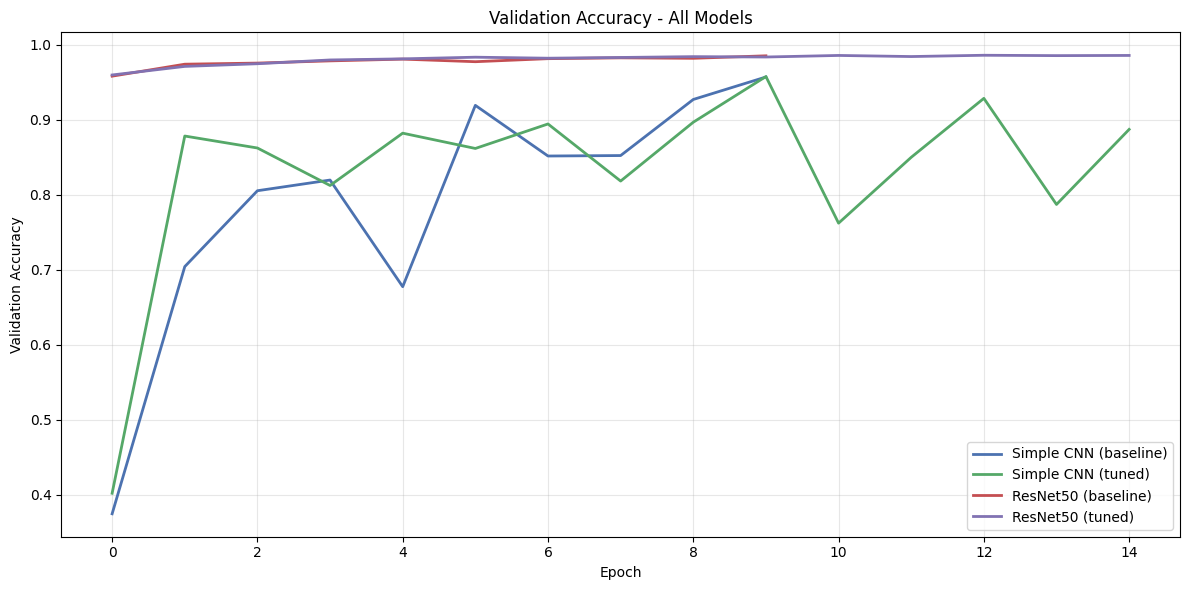

In [ ]:
# Plot validation accuracy curves for all 4 models
plt.figure(figsize=(12, 6))

plt.plot(history.history['val_accuracy'],
         label='Simple CNN (baseline)', linewidth=2, color='#4C72B0')
plt.plot(history_best.history['val_accuracy'],
         label='Simple CNN (tuned)', linewidth=2, color='#55A868')
plt.plot(history_resnet.history['val_accuracy'],
         label='ResNet50 (baseline)', linewidth=2, color='#C44E52')
plt.plot(history_resnet_best.history['val_accuracy'],
         label='ResNet50 (tuned)', linewidth=2, color='#8172B2')

plt.title('Validation Accuracy - All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Συλλογη μετρικων και εξαγωγη σε JSON

Πεαρ απο accuracy, μαζευω και αλλες σημαντικες μετρικες απο τα 4 μοντελα και τα εξαγω σε ενα JSON αρχειο για περαιτερω αναλυση.

**Τι θα συλλεξω για καθε μοντελο:**

*Standard:*
- Test accuracy / Test loss
- **Top-3** και **Top-5** accuracy

*Aggregate (πανω σε ολες τις κλασεις):*
- **Precision / Recall / F1** (macro και weighted average)

*Ανθεκτικες σε class imbalance:*
- **Cohen's Kappa** (συμφωνια μετα την αφαιρεση τυχαιας συμφωνιας)
- **Matthews Correlation Coefficient (MCC)**
- **Balanced Accuracy** (μεσος ορος per-class recall)

*Πιθανοτητες:*
- **ROC-AUC** (one-vs-rest, macro & weighted)
- **Log loss** (cross-entropy)

*Confidence analysis:*
- Μεσο **confidence** σε σωστες vs λαθος προβλεψεις (αν το μοντελο ειναι «υπερβολικα σιγουρο» οταν κανει λαθος)

*Per-class detail:*
- **Classification report** (precision/recall/F1 ανα κατηγορια)
- **Per-class accuracy** και support
- **Confusion matrix**

*Speed & size:*
- **Inference time** ανα sample (ms)
- **Number of parameters** (total + trainable)

*Training:*
- **Training history** (train/val accuracy/loss ανα epoch)
- Καλυτερες υπερπαραμετροι και ολα τα tuner trials

### 18.1 Συναρτηση συλλογης μετρικων

Φτιαχνω μια συναρτηση που τρεχει predictions στο test set και υπολογιζει ολες τις μετρικες για ενα μοντελο.

In [ ]:
from sklearn.metrics import (
    classification_report, top_k_accuracy_score,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score, roc_auc_score, log_loss
)
import time

def collect_metrics(model, ds_test, model_name):
    """Run predictions on the test set and gather a rich set of metrics."""
    y_true_local, y_pred_local, y_proba_local = [], [], []

    # Time the inference
    start_time = time.time()
    n_samples = 0

    for images, labels in ds_test:
        proba = model.predict(images, verbose=0)
        y_true_local.extend(labels.numpy())
        y_pred_local.extend(np.argmax(proba, axis=1))
        y_proba_local.extend(proba)
        n_samples += len(labels.numpy())

    inference_time_total = time.time() - start_time
    inference_time_per_sample_ms = (inference_time_total / n_samples) * 1000

    y_true_arr = np.array(y_true_local)
    y_pred_arr = np.array(y_pred_local)
    y_proba_arr = np.array(y_proba_local)

    # Test loss and accuracy from the model
    test_loss_m, test_acc_m = model.evaluate(ds_test, verbose=0)

    # Top-k accuracy
    top3 = top_k_accuracy_score(y_true_arr, y_proba_arr, k=3, labels=list(range(NUM_CLASSES)))
    top5 = top_k_accuracy_score(y_true_arr, y_proba_arr, k=5, labels=list(range(NUM_CLASSES)))

    # Per-class precision/recall/F1
    report = classification_report(
        y_true_arr, y_pred_arr,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    macro_avg = report['macro avg']
    weighted_avg = report['weighted avg']

    # Per-class accuracy and support
    per_class_acc = {}
    per_class_support = {}
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_true_arr == cls_idx
        per_class_support[cls_name] = int(mask.sum())
        per_class_acc[cls_name] = float((y_pred_arr[mask] == cls_idx).mean()) if mask.sum() > 0 else None

    # Confusion matrix
    cm = confusion_matrix(y_true_arr, y_pred_arr).tolist()

    # Robust metrics for class imbalance
    kappa = cohen_kappa_score(y_true_arr, y_pred_arr)
    mcc = matthews_corrcoef(y_true_arr, y_pred_arr)
    bal_acc = balanced_accuracy_score(y_true_arr, y_pred_arr)

    # ROC-AUC (one-vs-rest)
    try:
        roc_auc_macro = float(roc_auc_score(y_true_arr, y_proba_arr, multi_class='ovr', average='macro'))
    except Exception:
        roc_auc_macro = None
    try:
        roc_auc_weighted = float(roc_auc_score(y_true_arr, y_proba_arr, multi_class='ovr', average='weighted'))
    except Exception:
        roc_auc_weighted = None

    # Log loss
    try:
        ll = float(log_loss(y_true_arr, y_proba_arr, labels=list(range(NUM_CLASSES))))
    except Exception:
        ll = None

    # Confidence analysis: how confident is the model when correct vs incorrect?
    confidences = np.max(y_proba_arr, axis=1)
    correct_mask = (y_pred_arr == y_true_arr)
    mean_conf_overall = float(confidences.mean())
    mean_conf_correct = float(confidences[correct_mask].mean()) if correct_mask.sum() > 0 else None
    mean_conf_incorrect = float(confidences[~correct_mask].mean()) if (~correct_mask).sum() > 0 else None

    # Trainable params count
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_variables))

    return {
        'name': model_name,
        # Standard
        'test_accuracy': float(test_acc_m),
        'test_loss': float(test_loss_m),
        'top_3_accuracy': float(top3),
        'top_5_accuracy': float(top5),
        # Aggregate
        'precision_macro': float(macro_avg['precision']),
        'recall_macro': float(macro_avg['recall']),
        'f1_macro': float(macro_avg['f1-score']),
        'precision_weighted': float(weighted_avg['precision']),
        'recall_weighted': float(weighted_avg['recall']),
        'f1_weighted': float(weighted_avg['f1-score']),
        # Robust to class imbalance
        'cohen_kappa': float(kappa),
        'matthews_corrcoef': float(mcc),
        'balanced_accuracy': float(bal_acc),
        # Probabilistic
        'roc_auc_macro_ovr': roc_auc_macro,
        'roc_auc_weighted_ovr': roc_auc_weighted,
        'log_loss': ll,
        # Confidence
        'mean_confidence': mean_conf_overall,
        'mean_confidence_correct': mean_conf_correct,
        'mean_confidence_incorrect': mean_conf_incorrect,
        # Speed
        'inference_time_total_sec': float(inference_time_total),
        'inference_time_per_sample_ms': float(inference_time_per_sample_ms),
        'num_test_samples': int(n_samples),
        # Detailed
        'classification_report': report,
        'per_class_accuracy': per_class_acc,
        'per_class_support': per_class_support,
        'confusion_matrix': cm,
        # Model size
        'num_total_params': int(model.count_params()),
        'num_trainable_params': trainable,
    }

print("collect_metrics function ready (extended)")

collect_metrics function ready (extended)


### 18.2 Συλλογη μετρικων για τα 4 μοντελα

Τρεχω τη συναρτηση για ολα τα μοντελα και τυπωνω ενα συγκριτικο πινακα με τις κυριες μετρικες.

In [ ]:
# Collect metrics for all 4 models
print("Collecting metrics for Simple CNN (baseline)...")
metrics_simple = collect_metrics(model, ds_test_prepared, 'Simple CNN (baseline)')

print("Collecting metrics for Simple CNN (tuned)...")
metrics_simple_tuned = collect_metrics(best_model, ds_test_prepared, 'Simple CNN (tuned)')

print("Collecting metrics for ResNet50 (baseline)...")
metrics_resnet = collect_metrics(model_resnet, ds_test_resnet, 'ResNet50 (baseline)')

print("Collecting metrics for ResNet50 (tuned)...")
metrics_resnet_tuned = collect_metrics(best_model_resnet, ds_test_resnet, 'ResNet50 (tuned)')

# Summary table
all_metrics = [metrics_simple, metrics_simple_tuned, metrics_resnet, metrics_resnet_tuned]

print("\n" + "=" * 110)
print(f"{'Model':<26} {'Acc':>7} {'Top-3':>7} {'F1-mac':>8} {'Kappa':>7} {'MCC':>7} {'BalAcc':>8} {'AUC-mac':>9} {'ms/img':>8}")
print("=" * 110)
for m in all_metrics:
    print(f"{m['name']:<26} "
          f"{m['test_accuracy']*100:>6.2f}% "
          f"{m['top_3_accuracy']*100:>6.2f}% "
          f"{m['f1_macro']:>8.4f} "
          f"{m['cohen_kappa']:>7.4f} "
          f"{m['matthews_corrcoef']:>7.4f} "
          f"{m['balanced_accuracy']:>8.4f} "
          f"{(m['roc_auc_macro_ovr'] or 0):>9.4f} "
          f"{m['inference_time_per_sample_ms']:>7.2f}")
print("=" * 110)
print("\nConfidence analysis (mean prediction confidence):")
print(f"{'Model':<26} {'Overall':>10} {'On Correct':>12} {'On Incorrect':>14}")
for m in all_metrics:
    print(f"{m['name']:<26} "
          f"{m['mean_confidence']*100:>9.2f}% "
          f"{(m['mean_confidence_correct'] or 0)*100:>11.2f}% "
          f"{(m['mean_confidence_incorrect'] or 0)*100:>13.2f}%")


Model                          Acc   Top-3   F1-mac   Kappa     MCC   BalAcc   AUC-mac   ms/img
Simple CNN (baseline)       95.75%  99.79%   0.9463  0.9554  0.9555   0.9386    0.9998    1.28
Simple CNN (tuned)          88.73%  97.05%   0.8486  0.8815  0.8821   0.8372    0.9981    1.63
ResNet50 (baseline)         98.61%  99.96%   0.9802  0.9854  0.9854   0.9765    0.9999    3.09
ResNet50 (tuned)            98.65%  99.89%   0.9813  0.9858  0.9858   0.9801    0.9999    3.11

Confidence analysis (mean prediction confidence):
Model                         Overall   On Correct   On Incorrect
Simple CNN (baseline)          96.57%       97.55%         74.58%
Simple CNN (tuned)             93.29%       95.94%         72.37%
ResNet50 (baseline)            98.67%       99.01%         74.52%
ResNet50 (tuned)               99.01%       99.31%         76.70%


### 18.3 Δομηση πληρους dictionary με ολα τα αποτελεσματα

Μαζευω metadata, μετρικες, training histories, καλυτερες υπερπαραμετρους και ολα τα tuner trials σε ενα ενιαιο dictionary.

In [ ]:
from datetime import datetime

def history_to_floats(hist_dict):
    """Convert keras history values to plain Python floats for JSON."""
    return {k: [float(v) for v in vals] for k, vals in hist_dict.items()}

def collect_tuner_trials(tuner_obj):
    """Collect all trial results from a Keras Tuner."""
    trials = []
    for trial_id, trial in tuner_obj.oracle.trials.items():
        trials.append({
            'trial_id': trial_id,
            'score': float(trial.score) if trial.score is not None else None,
            'hyperparameters': dict(trial.hyperparameters.values),
        })
    trials.sort(key=lambda t: (t['score'] is None, -(t['score'] or 0)))
    return trials

# Build the comprehensive results dictionary
all_results = {
    'metadata': {
        'dataset': 'PlantVillage',
        'num_classes': int(NUM_CLASSES),
        'class_names': list(CLASS_NAMES),
        'split_percentages': {'train': 70, 'val': 15, 'test': 15},
        'total_images': int(info.splits['train'].num_examples),
        'image_size_simple_cnn': IMG_SIZE,
        'image_size_resnet': IMG_SIZE_RESNET,
        'batch_size': BATCH_SIZE,
        'tf_version': tf.__version__,
        'timestamp': datetime.now().isoformat(),
    },
    'models': {
        'simple_baseline': {
            **metrics_simple,
            'history': history_to_floats(history.history),
            'epochs_trained': len(history.history['accuracy']),
            'hyperparameters': {
                'dropout': 0.4, 'dense_units': 128,
                'learning_rate': 1e-3, 'optimizer': 'Adam',
            },
        },
        'simple_tuned': {
            **metrics_simple_tuned,
            'history': history_to_floats(history_best.history),
            'epochs_trained': len(history_best.history['accuracy']),
            'hyperparameters': {
                'dropout': float(best_hps.get('dropout')),
                'dense_units': int(best_hps.get('dense_units')),
                'learning_rate': float(best_hps.get('learning_rate')),
                'optimizer': 'Adam',
            },
        },
        'resnet_baseline': {
            **metrics_resnet,
            'history': history_to_floats(history_resnet.history),
            'epochs_trained': len(history_resnet.history['accuracy']),
            'hyperparameters': {
                'dropout': 0.4, 'dense_units': 128,
                'learning_rate': 1e-3, 'optimizer': 'Adam',
                'backbone_frozen': True,
            },
        },
        'resnet_tuned': {
            **metrics_resnet_tuned,
            'history': history_to_floats(history_resnet_best.history),
            'epochs_trained': len(history_resnet_best.history['accuracy']),
            'hyperparameters': {
                'dropout': float(best_hps_resnet.get('dropout')),
                'dense_units': int(best_hps_resnet.get('dense_units')),
                'learning_rate': float(best_hps_resnet.get('learning_rate')),
                'optimizer': 'Adam',
                'backbone_frozen': True,
            },
        },
    },
    'tuner_trials': {
        'simple_cnn': collect_tuner_trials(tuner),
        'resnet': collect_tuner_trials(tuner_resnet),
    },
}

print("Full results dictionary built")
print(f"  Top-level keys: {list(all_results.keys())}")
print(f"  Models tracked: {list(all_results['models'].keys())}")
print(f"  Simple CNN tuner trials: {len(all_results['tuner_trials']['simple_cnn'])}")
print(f"  ResNet tuner trials:     {len(all_results['tuner_trials']['resnet'])}")

Full results dictionary built
  Top-level keys: ['metadata', 'models', 'tuner_trials']
  Models tracked: ['simple_baseline', 'simple_tuned', 'resnet_baseline', 'resnet_tuned']
  Simple CNN tuner trials: 5
  ResNet tuner trials:     5


### 18.4 Εξαγωγη σε JSON και download

Αποθηκευω το dictionary σε JSON αρχειο και το κατεβαζω τοπικα.

In [ ]:
import os, json

# Save to JSON
output_filename = 'plant_disease_results.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

size_kb = os.path.getsize(output_filename) / 1024
print(f"Saved results to '{output_filename}' ({size_kb:.1f} KB)")

# Trigger download in Colab
try:
    from google.colab import files
    files.download(output_filename)
    print("Download started in Colab")
except ImportError:
    print(f"Not running in Colab. File saved at: {os.path.abspath(output_filename)}")

Saved results to 'plant_disease_results.json' (135.6 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started in Colab


## Συμπερασματα

Εχτισα και συγκρινα **4 μοντελα** για ταξινομηση 38 κατηγοριων ασθενειων φυτων στο PlantVillage dataset:

1. **Simple CNN (baseline)** - 4 conv blocks, χειροκινητες υπερπαραμετροι
2. **Simple CNN (tuned)** - tuned με RandomSearch (dropout, dense_units, learning_rate)
3. **ResNet50 (baseline)** - transfer learning με frozen ImageNet backbone
4. **ResNet50 (tuned)** - tuned classification head πανω σε frozen ResNet50

**Τι εκανα:**
- Σχεδιασα custom CNN αρχιτεκτονικη απο την αρχη
- Εστησα data pipelines (με/χωρις ResNet-specific preprocessing)
- Εκανα data augmentation (random flip + brightness)
- Εφαρμοσα **transfer learning** με ResNet50 (50 layers, ImageNet weights)
- Εκανα **hyperparameter tuning** με Keras Tuner RandomSearch και στα δυο μοντελα
- Συγκρινα και τα 4 μοντελα σε confusion matrix, sample predictions και test accuracy

**Επομενα βηματα:**
- Δοκιμη με αλλα pretrained models (MobileNetV2, EfficientNet)
- Hyperband αντι για RandomSearch
- Πιο επιθετικο data augmentation

In [ ]:
# Strip widget metadata before downloading the notebook
import json
from google.colab import _message

# Get current notebook content
notebook_json = _message.blocking_request('get_ipynb', timeout_sec=30)['ipynb']

# Remove broken widgets metadata
if 'widgets' in notebook_json.get('metadata', {}):
    del notebook_json['metadata']['widgets']

# Save cleaned version
with open('plant_disease_cnn_clean.ipynb', 'w') as f:
    json.dump(notebook_json, f, indent=1)

# Download the clean version
from google.colab import files
files.download('plant_disease_cnn_clean.ipynb')
